## This notebook is intended to load processed EXAFS data and construct a 'botom up' model via specific path selection and parameter linking. 

In [1]:
# step 0: imports
import sys
sys.path.insert(0, r"C:\Users\kwill\Keenan_UCB-O365\OneDrive_UCB-O365\GitHub_Repos\xraylarch")
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.interpolate import interp1d
from larch.io import read_athena, read_ascii
from larch.xafs import (pre_edge, autobk, xftf, 
                        ff2chi, feffpath, feffit_transform, feffit_dataset, feffit, feffit_report, TransformGroup, path2chi)
from larch.fitting import param, guess, param_group
from larch.plot.plotly_xafsplots import (plot_mu, plot_chik, plot_chir, plot_chifit, 
                                         multi_plot, plotlabels, set_label_weight)
from larch.utils import group2dict
from pathlib import Path
from larch.wxlib import plotlabels as plab 
from scipy.signal import savgol_filter   
try:
    # Try the newer name first
    from scipy.integrate import simpson as integrate_method
except ImportError:
    try:
        # Try the older name
        from scipy.integrate import simps as integrate_method
    except ImportError:
        # Fall back to trapz which is always available
        from scipy.integrate import trapz as integrate_method
        print("Note: Using trapz for integration instead of simpson/simps")      
import matplotlib.cm as cm  
from larch import Group                                
import os 

from larch.XASmu2r import XASmu2r
from larch.XAFSfit import XAFSfit
# initialize the fit object with the directory containing the processed Athena files
cspbi3_fit = XAFSfit(
    Path(r'C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\CsPbI3\low_noise\processed')
)



LOAD PROCESSED CHECKPOINT SUMMARY
  Processed folder:  C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\CsPbI3\low_noise\processed
  Checkpoint file:   C:\Users\kwill\Keenan_UCB-O365\OneDrive - UCB-O365\Data\XAS\NSLS-II\AthenaProjectFiles\CsPbI3\low_noise\processed\processed_checkpoint.pkl
  Projects loaded:   11
  Groups loaded:     20


## Bottom-Up Iterative Fitting Procedure
### By Iteration:
##### First: Add Pb-I scattering path and plot fit summary
##### Second: Add Pb-O scattering path and plot fit summary
##### Second (replacement): Reevaluate all Pb-I paths, then Pb-O for better fit and plot fit summary
##### Third: Add Pb-S scattering path with parameters linked to Pb-O and plot fit summary
##### Third (replacement): Reevaluate all Pb-O, Pb-I, and Pb-S scattering paths for better fit and plot fit summary
##### Fourth: Add Pb-C scattering path with parameters linked to Pb-O
##### Fourth (replacement): Reevaluate Pb-O, Pb-S, Pb-I, and Pb-C for better fit and plot fit summary
##### Fifth: Add linked multiple scattering and plot fit summary
##### Fifth (final): Reevaluate All paths in model, relax e0 in arguement and plot fit summary and publication figure.   


In [2]:
feff_dir = r'C:/Users/kwill/.larch/feff' 


Searching for and analyzing Pb-I FEFF paths in C:\Users\kwill\.larch\feff
Found 819 Pb-I FEFF paths.

Detailed information about Pb-I paths:
Index  Type   Reff     Deg    n-leg  Label
--------------------------------------------------------------------------------
     1 ss     2.689 Å      1      2  Pb-I SS: 2.689Å
     2 ss     2.812 Å      1      2  Pb-I SS: 2.812Å
     3 ss     2.819 Å      1      2  Pb-I SS: 2.819Å
     4 ss     2.843 Å      1      2  Pb-I SS: 2.843Å
     5 ss     2.881 Å      1      2  Pb-I SS: 2.881Å
     6 ss     2.890 Å      1      2  Pb-I SS: 2.890Å
     7 ss     2.891 Å      1      2  Pb-I SS: 2.891Å
     8 ss     2.899 Å      1      2  Pb-I SS: 2.899Å
     9 ss     2.899 Å      1      2  Pb-I SS: 2.899Å
    10 ss     2.923 Å      1      2  Pb-I SS: 2.923Å
    11 ss     2.924 Å      1      2  Pb-I SS: 2.924Å
    12 ss     2.924 Å      1      2  Pb-I SS: 2.924Å
    13 ss     2.924 Å      1      2  Pb-I SS: 2.924Å
    14 ss     2.932 Å      1      2  Pb-I SS:

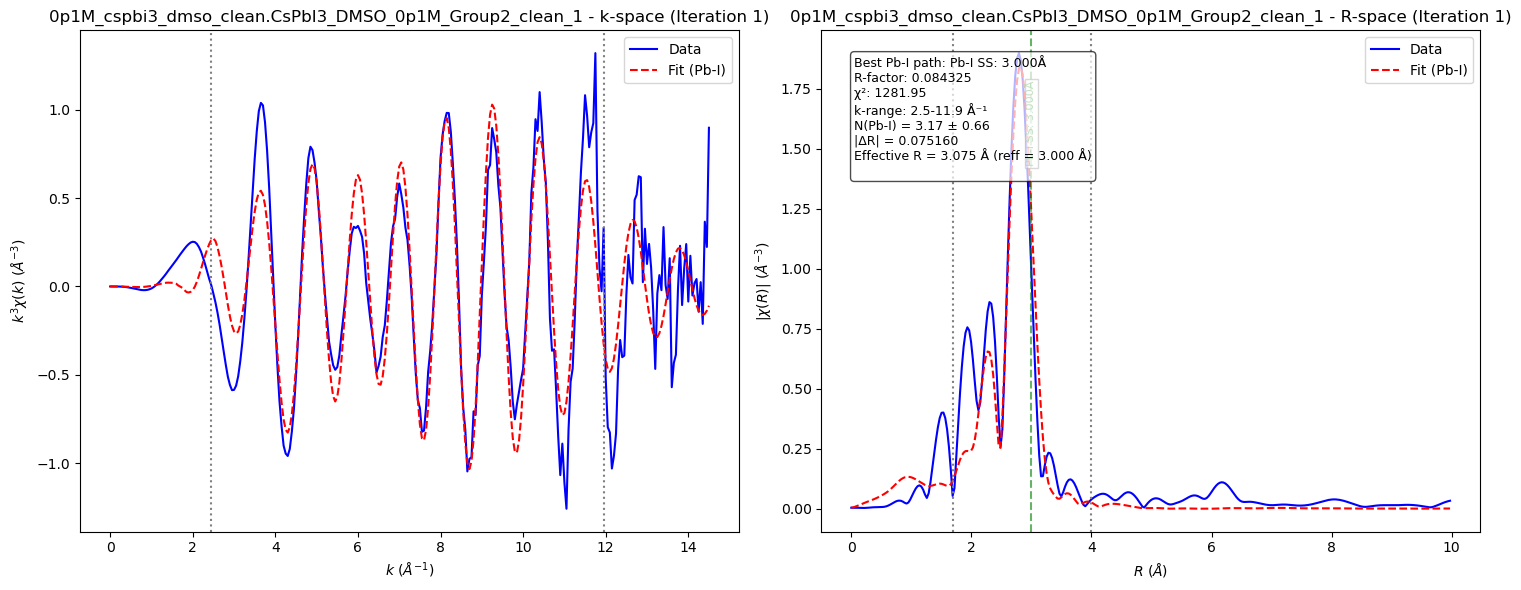


Processing Group: 0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1M_Group1_clean_smooth

Processing group: 0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1M_Group1_clean_smooth
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.45 (from ft_processing_batch)
  Found optimized kmax = 11.85 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.72 A (detected)
  Created transform with k-range: 2.45 to 11.85 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1M_Group1_clean_smooth...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x14408547e60>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.055, R-factor: 1.042910
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440c4eae70>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.095, R-factor: 1.053578
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440c492780>
  Pat

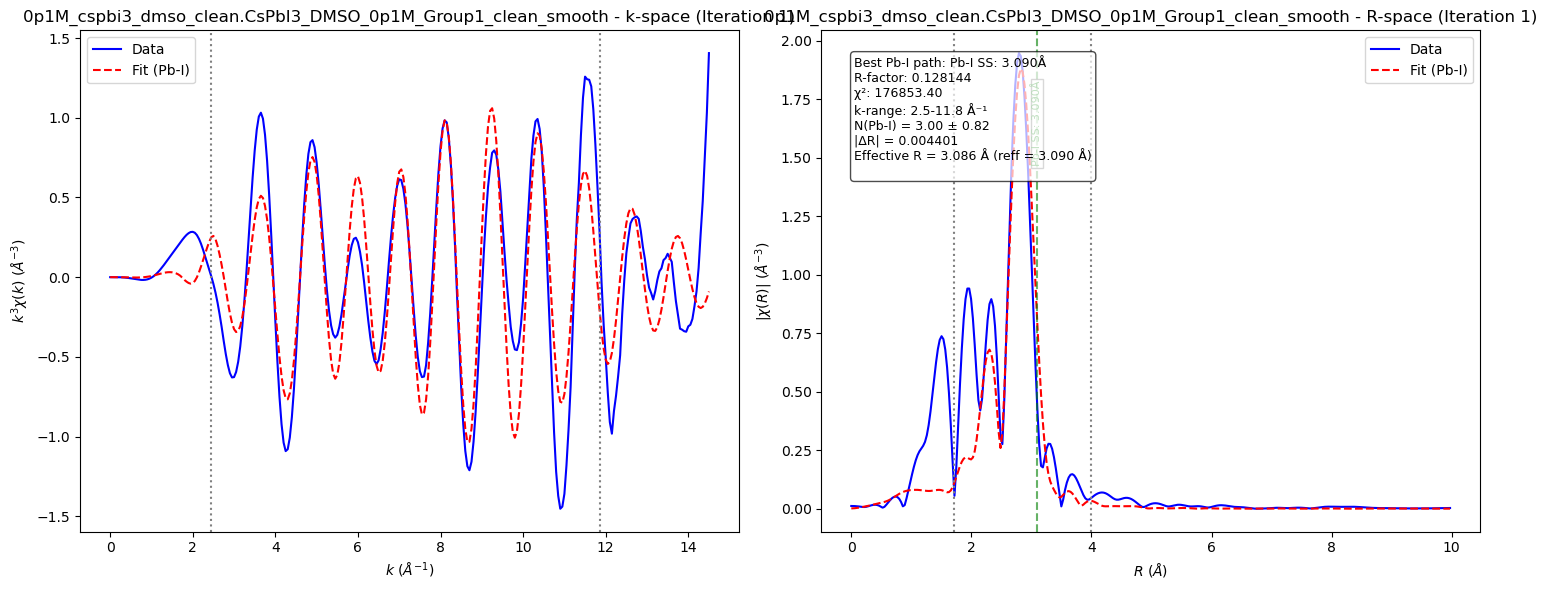


Processing Group: 0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1m_Group3_clean_deconv

Processing group: 0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1m_Group3_clean_deconv
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.35 (from ft_processing_batch)
  Found optimized kmax = 11.95 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.35 to 11.95 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1m_Group3_clean_deconv...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b10f590>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.048, R-factor: 1.012193
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x14409e1a150>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.088, R-factor: 1.025495
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440c937f80>
  Pat

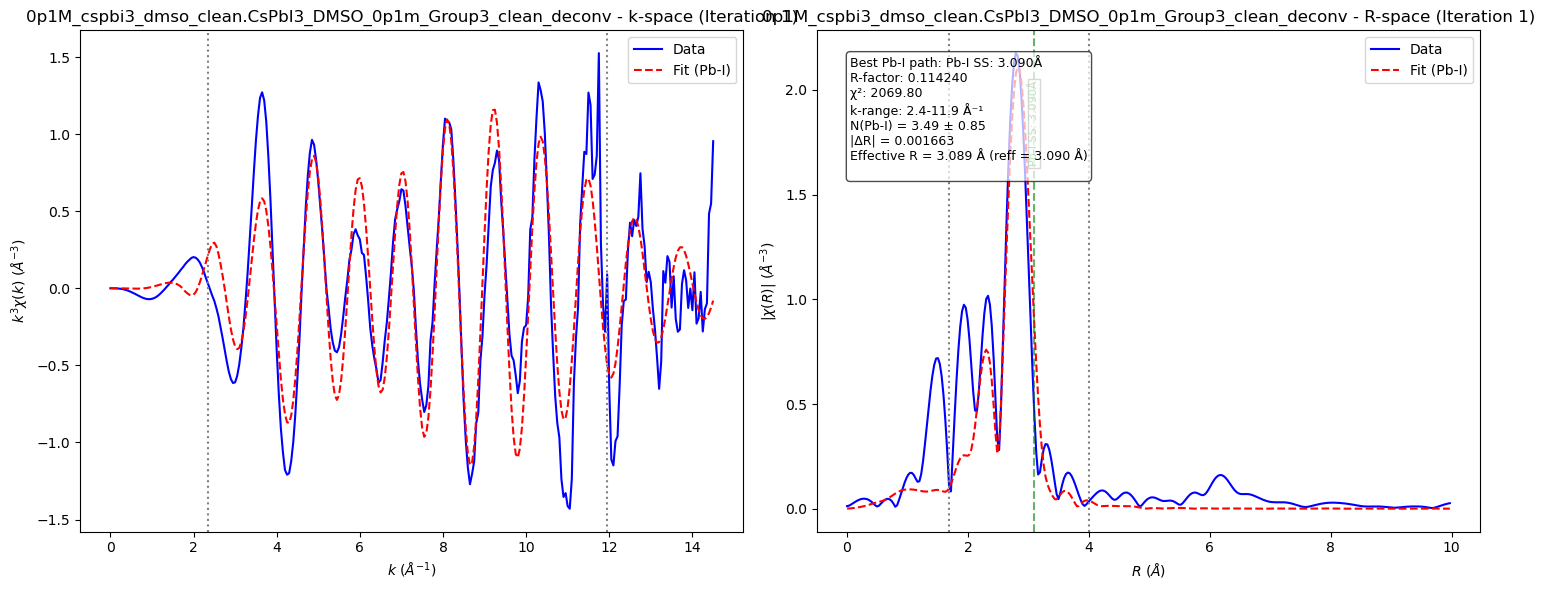


Processing Project: 0p2M_cspbi3_dmso_clean

Processing Group: 0p2M_cspbi3_dmso_clean.CsPbI3_DMSO_0p2M_Group1_clean

Processing group: 0p2M_cspbi3_dmso_clean.CsPbI3_DMSO_0p2M_Group1_clean
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.40 (from ft_processing_batch)
  Found optimized kmax = 11.75 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.66 A (detected)
  Created transform with k-range: 2.40 to 11.75 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p2M_cspbi3_dmso_clean.CsPbI3_DMSO_0p2M_Group1_clean...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440db35760>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.041, R-factor: 0.978006
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dd631d0>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.082, R-factor: 0.990705
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Gro

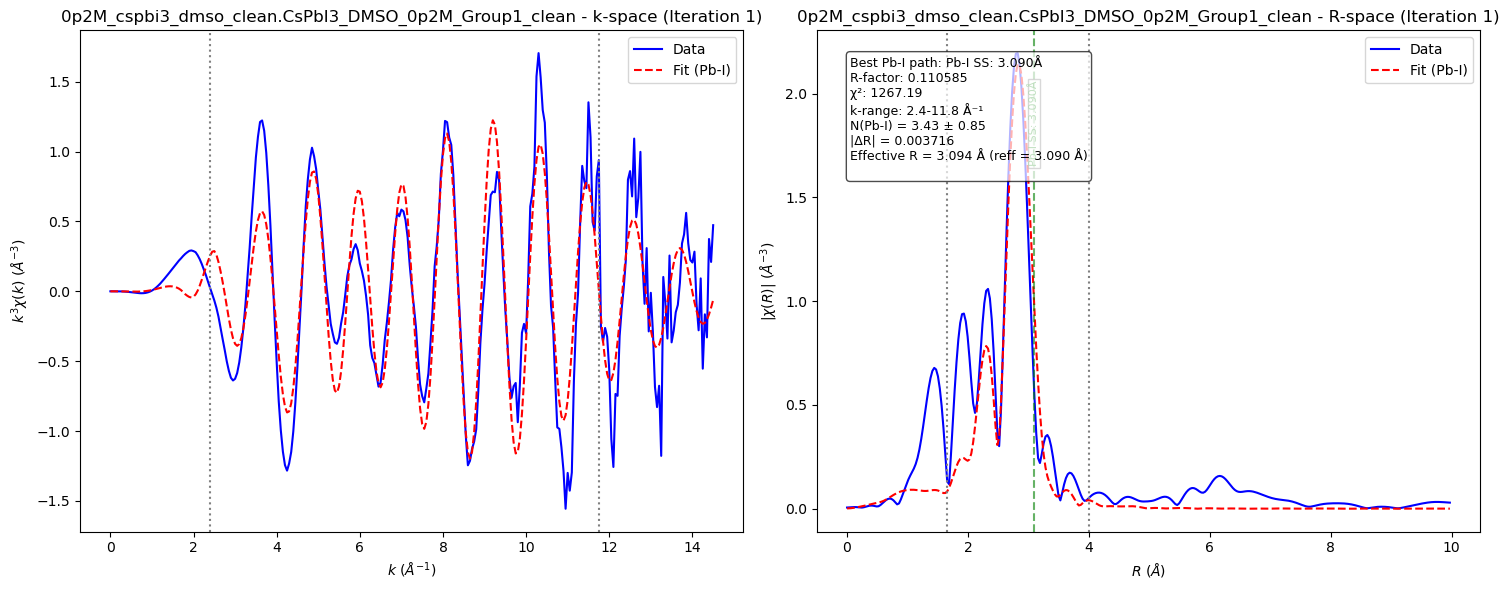


Processing Group: 0p2M_cspbi3_dmso_clean.CsPbI3_DMSO_0p2M_Group2

Processing group: 0p2M_cspbi3_dmso_clean.CsPbI3_DMSO_0p2M_Group2
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.45 (from ft_processing_batch)
  Found optimized kmax = 11.80 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.66 A (detected)
  Created transform with k-range: 2.45 to 11.80 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p2M_cspbi3_dmso_clean.CsPbI3_DMSO_0p2M_Group2...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440ca924b0>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.041, R-factor: 0.992009
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x14409e1a150>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.082, R-factor: 0.999522
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440c9e0e60>
  Path 3: Pb-I SS: 2.881Å - |ΔR|: 0.110, R-f

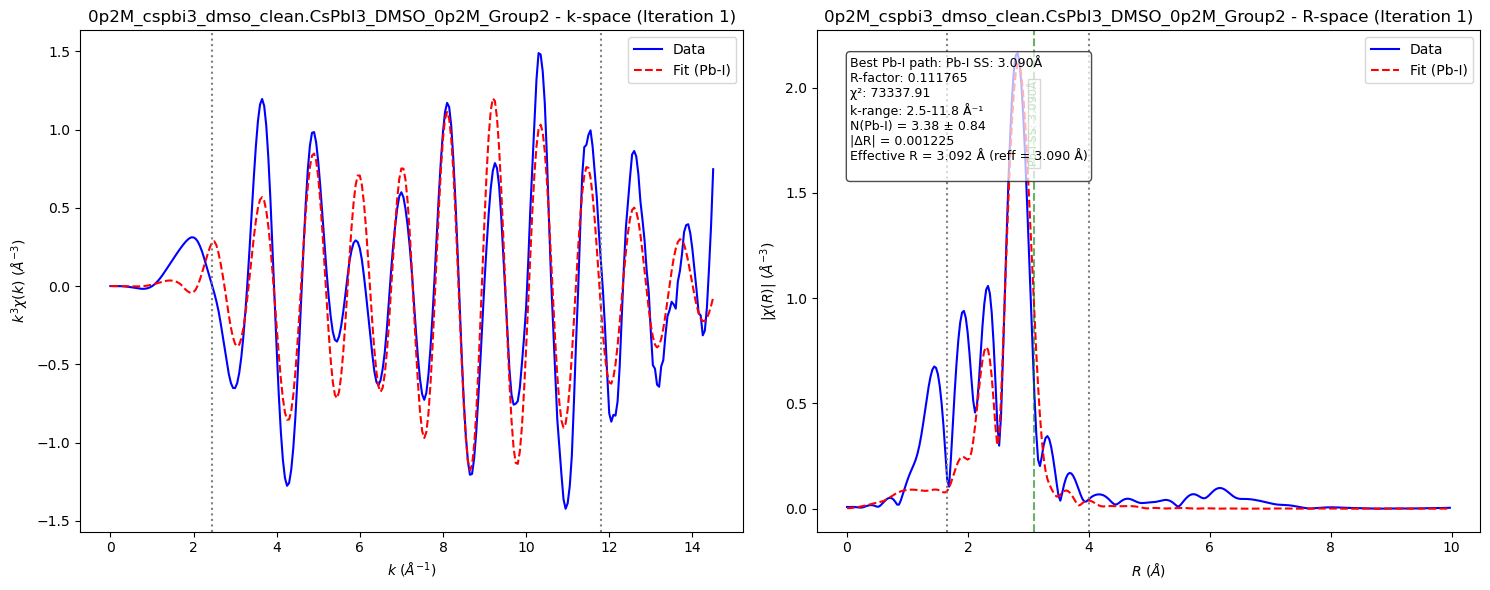


Processing Project: 0p3M_cspbi3_dmso_clean

Processing Group: 0p3M_cspbi3_dmso_clean.CsPbI3_DMSO_0p3M_Group1

Processing group: 0p3M_cspbi3_dmso_clean.CsPbI3_DMSO_0p3M_Group1
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.40 (from ft_processing_batch)
  Found optimized kmax = 11.85 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.40 to 11.85 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p3M_cspbi3_dmso_clean.CsPbI3_DMSO_0p3M_Group1...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x14409d42c00>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.045, R-factor: 1.006440
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dc86c00>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.086, R-factor: 1.017479
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440681a150>


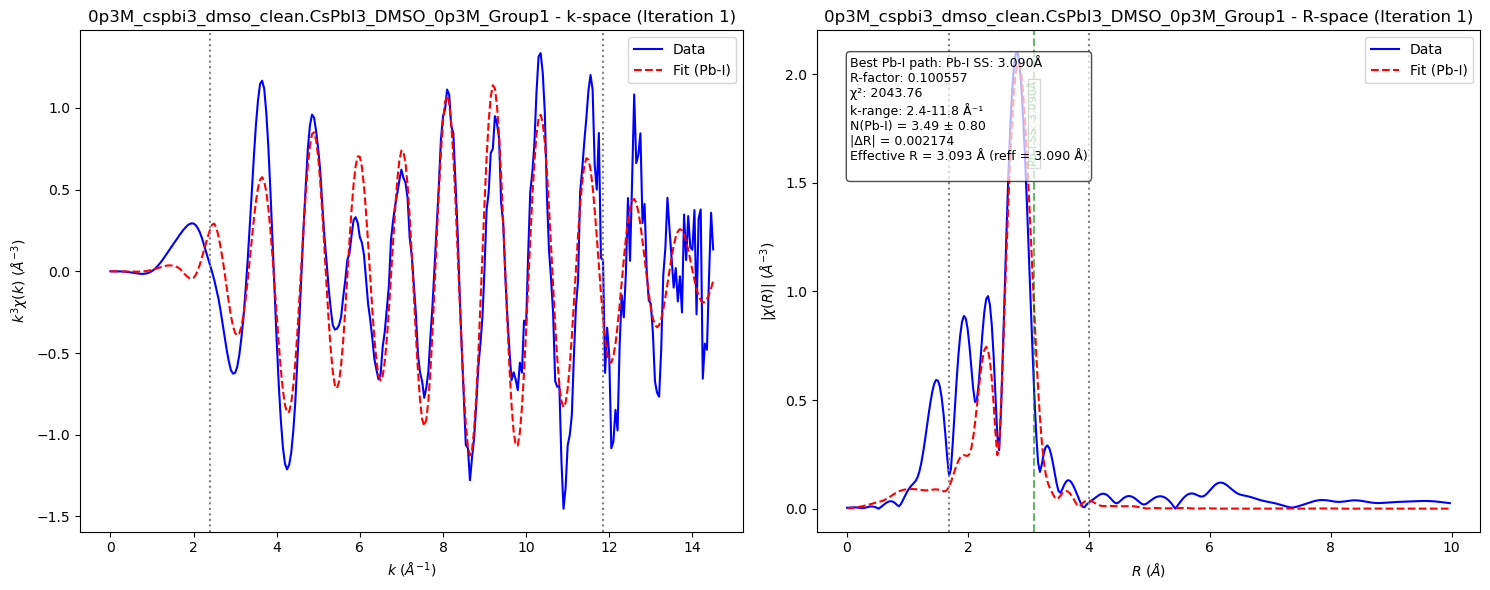


Processing Project: 0p4M_cspbi3_dmso_clean

Processing Group: 0p4M_cspbi3_dmso_clean.CsPbI3_DMSO_0p4M_Group1

Processing group: 0p4M_cspbi3_dmso_clean.CsPbI3_DMSO_0p4M_Group1
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.45 (from ft_processing_batch)
  Found optimized kmax = 11.80 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.45 to 11.80 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p4M_cspbi3_dmso_clean.CsPbI3_DMSO_0p4M_Group1...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b0bb230>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.050, R-factor: 1.004281
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b10c200>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.092, R-factor: 1.017940
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dd30c50>


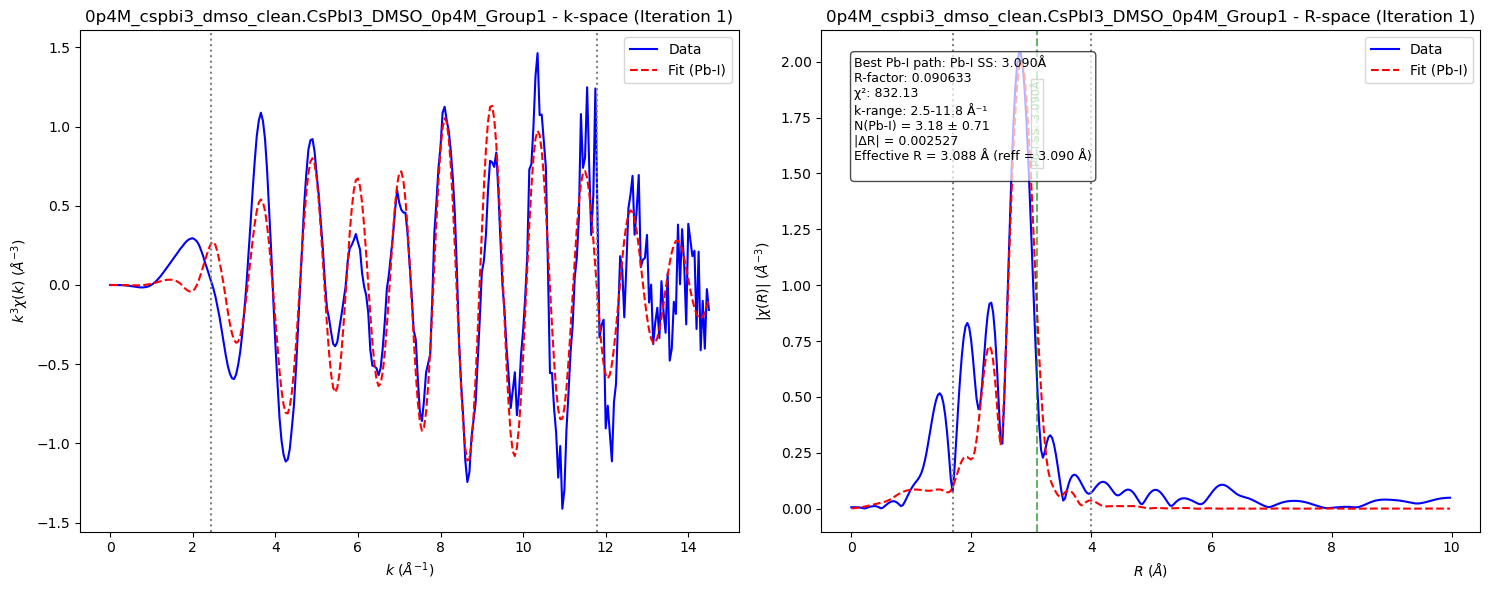


Processing Group: 0p4M_cspbi3_dmso_clean.CsPbI3_DMSO_0p4M_Group2

Processing group: 0p4M_cspbi3_dmso_clean.CsPbI3_DMSO_0p4M_Group2
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.45 (from ft_processing_batch)
  Found optimized kmax = 11.85 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.45 to 11.85 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p4M_cspbi3_dmso_clean.CsPbI3_DMSO_0p4M_Group2...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440df3fe90>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.051, R-factor: 1.018217
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440de8a150>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.092, R-factor: 1.028173
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b10d520>
  Path 3: Pb-I SS: 2.881Å - |ΔR|: 0.120, R-f

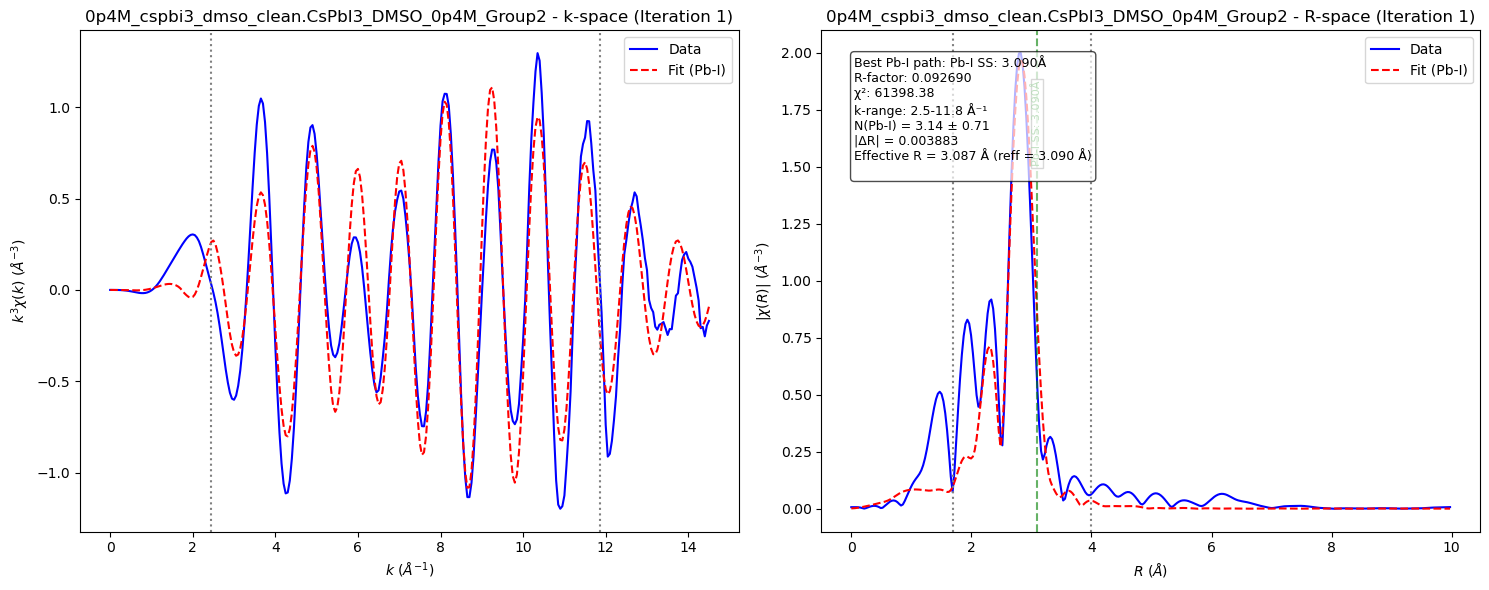


Processing Project: 0p5M_cspbi3_dmso_clean

Processing Group: 0p5M_cspbi3_dmso_clean.CsPbI3_DMSO_0p5M_Group1

Processing group: 0p5M_cspbi3_dmso_clean.CsPbI3_DMSO_0p5M_Group1
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.40 (from ft_processing_batch)
  Found optimized kmax = 11.75 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.40 to 11.75 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p5M_cspbi3_dmso_clean.CsPbI3_DMSO_0p5M_Group1...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440ca33e00>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.044, R-factor: 1.005802
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440838b320>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.085, R-factor: 1.013673
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440c56f830>


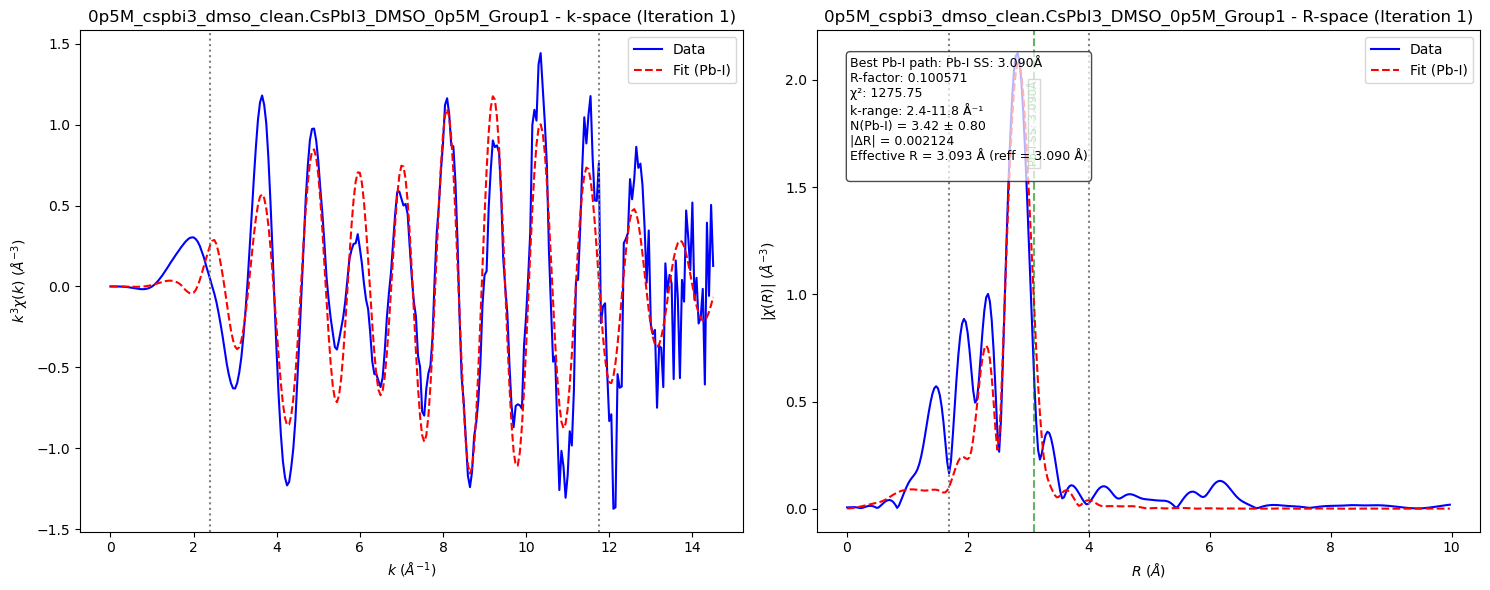


Processing Group: 0p5M_cspbi3_dmso_clean.CsPbI3_DMSO_0p5M_Group2

Processing group: 0p5M_cspbi3_dmso_clean.CsPbI3_DMSO_0p5M_Group2
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.45 (from ft_processing_batch)
  Found optimized kmax = 11.80 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.45 to 11.80 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p5M_cspbi3_dmso_clean.CsPbI3_DMSO_0p5M_Group2...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440cabb860>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.043, R-factor: 1.011568
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x14409dfa150>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.084, R-factor: 1.018184
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x14409dfa420>
  Path 3: Pb-I SS: 2.881Å - |ΔR|: 0.112, R-f

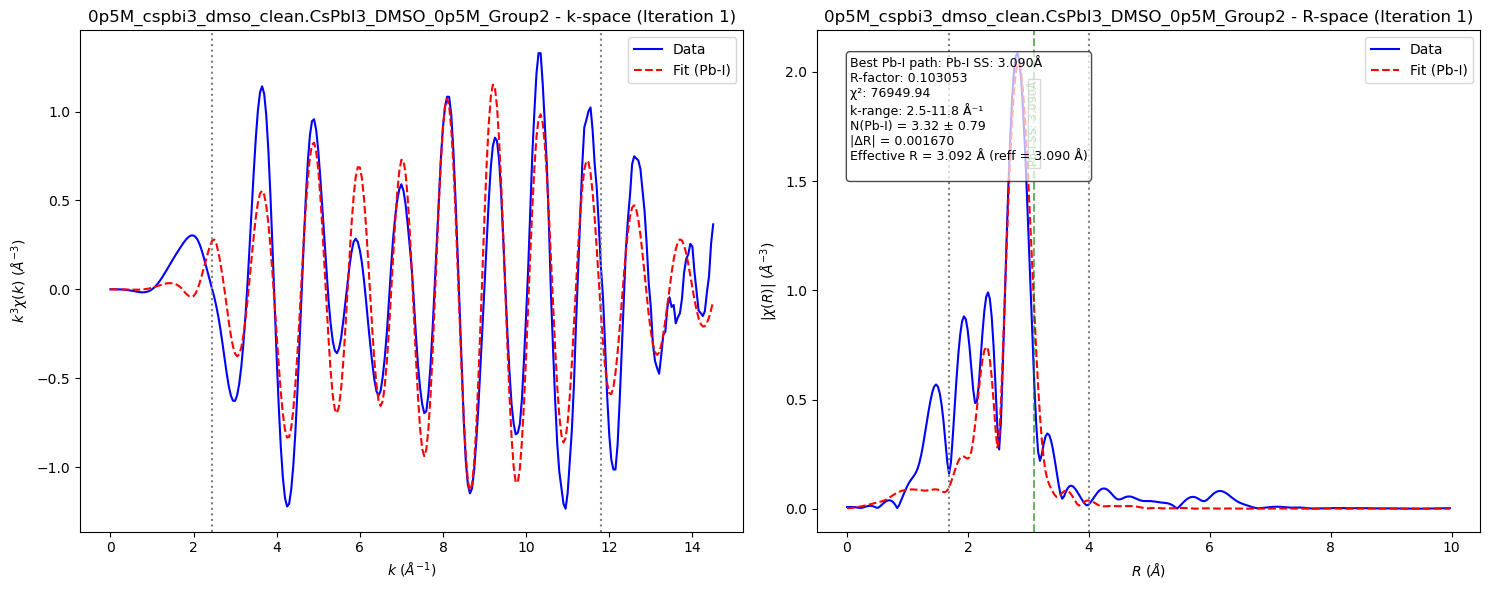


Processing Project: 0p6M_cspbi3_dmso_clean

Processing Group: 0p6M_cspbi3_dmso_clean.CsPbI3_DMSO_0p6M_Group1

Processing group: 0p6M_cspbi3_dmso_clean.CsPbI3_DMSO_0p6M_Group1
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.35 (from ft_processing_batch)
  Found optimized kmax = 11.75 (from ft_processing_batch)
  Using rbkg reference = 1.18 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.35 to 11.75 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p6M_cspbi3_dmso_clean.CsPbI3_DMSO_0p6M_Group1...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440c5987a0>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.062, R-factor: 1.115542
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dd615e0>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.099, R-factor: 1.118919
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b1c0ce0>


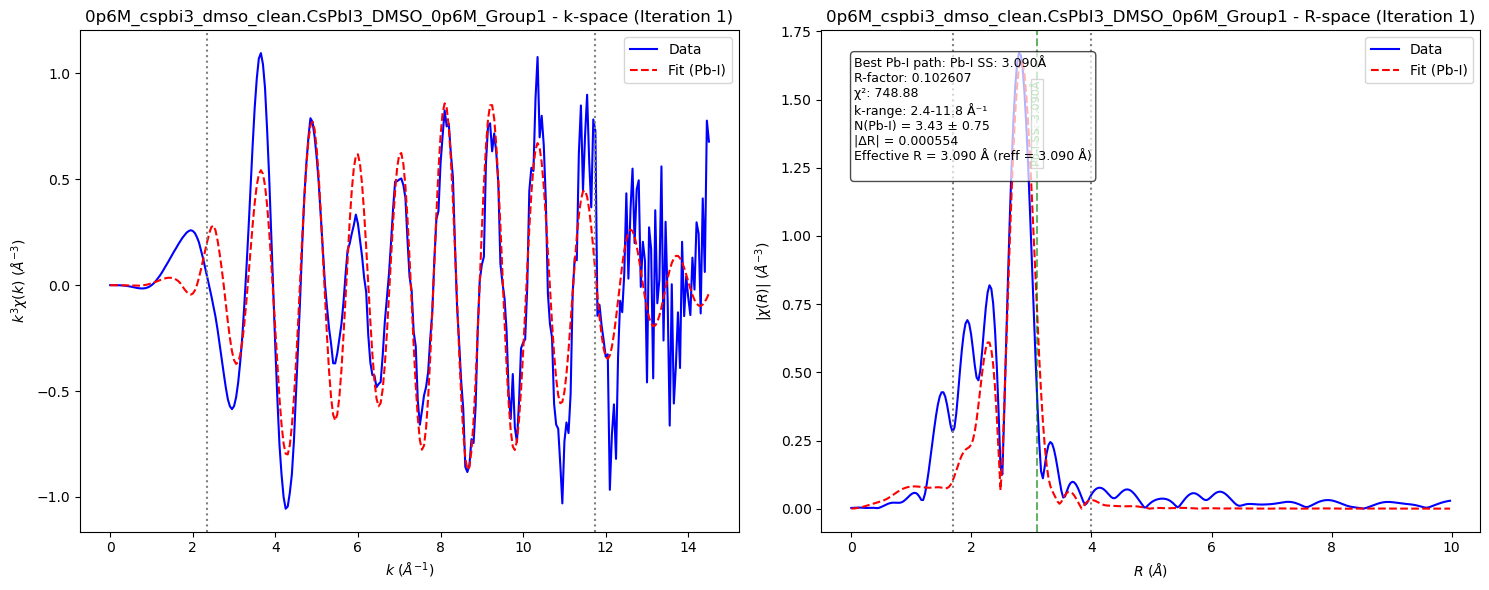


Processing Group: 0p6M_cspbi3_dmso_clean.CsPbI3_DMSO_0p6M_Group2

Processing group: 0p6M_cspbi3_dmso_clean.CsPbI3_DMSO_0p6M_Group2
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.40 (from ft_processing_batch)
  Found optimized kmax = 11.85 (from ft_processing_batch)
  Using rbkg reference = 1.18 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.40 to 11.85 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p6M_cspbi3_dmso_clean.CsPbI3_DMSO_0p6M_Group2...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dc86c90>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.062, R-factor: 1.126919
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dbb2150>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.099, R-factor: 1.126121
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dc316a0>
  Path 3: Pb-I SS: 2.881Å - |ΔR|: 0.132, R-f

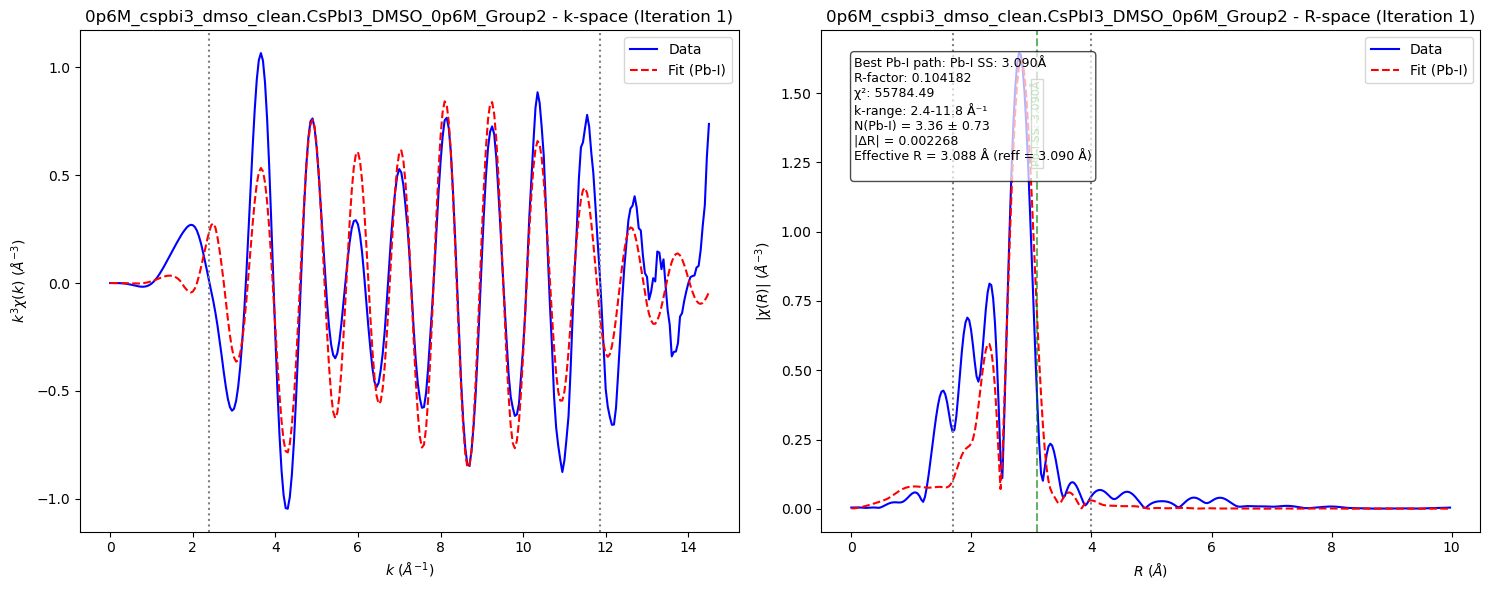


Processing Project: 0p7M_cspbi3_dmso_clean

Processing Group: 0p7M_cspbi3_dmso_clean.CsPbI3_DMSO_0p7M_Group1_clean

Processing group: 0p7M_cspbi3_dmso_clean.CsPbI3_DMSO_0p7M_Group1_clean
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.40 (from ft_processing_batch)
  Found optimized kmax = 11.75 (from ft_processing_batch)
  Using rbkg reference = 1.18 A
  Using fit rmin = 1.66 A (detected)
  Created transform with k-range: 2.40 to 11.75 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p7M_cspbi3_dmso_clean.CsPbI3_DMSO_0p7M_Group1_clean...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dc328a0>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.052, R-factor: 1.081462
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dce7f80>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.092, R-factor: 1.080938
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Gro

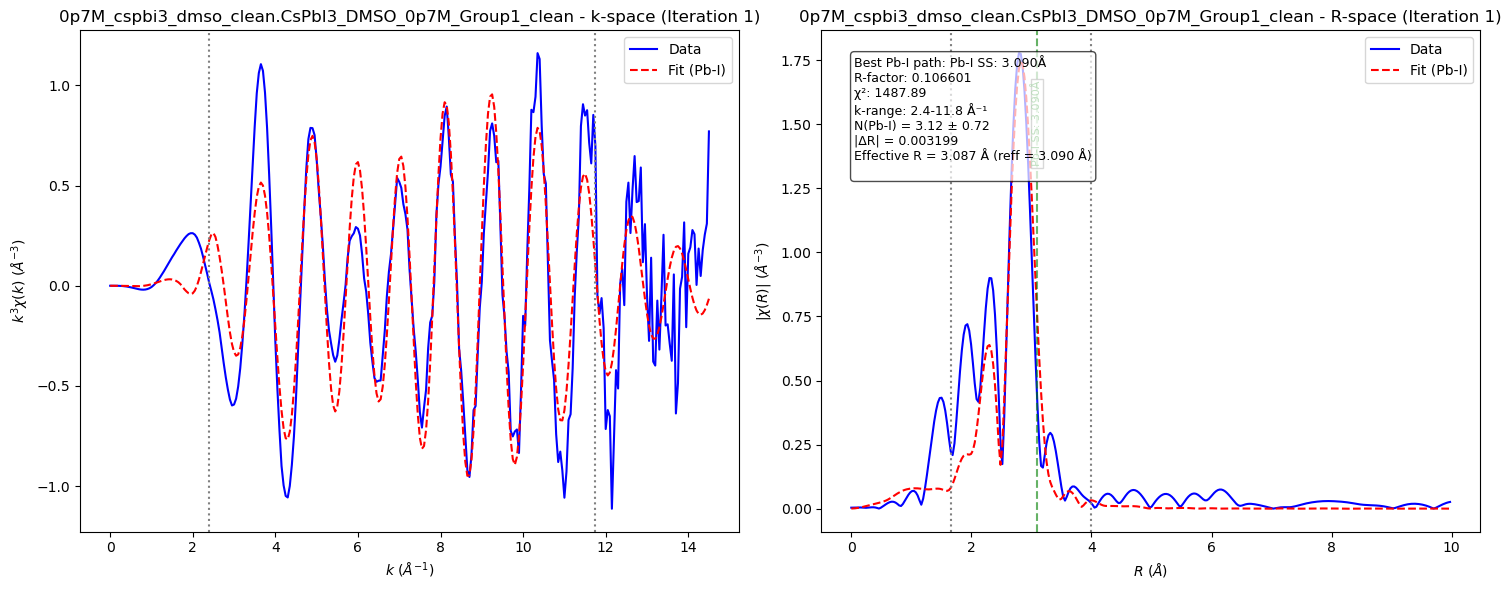


Processing Project: 0p8M_cspbi3_dmso_clean

Processing Group: 0p8M_cspbi3_dmso_clean.CsPbI3_DMSO_0p8M_Group1

Processing group: 0p8M_cspbi3_dmso_clean.CsPbI3_DMSO_0p8M_Group1
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.40 (from ft_processing_batch)
  Found optimized kmax = 11.75 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.40 to 11.75 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p8M_cspbi3_dmso_clean.CsPbI3_DMSO_0p8M_Group1...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440c9072f0>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.050, R-factor: 1.058889
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440f06b4a0>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.090, R-factor: 1.064506
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b092150>


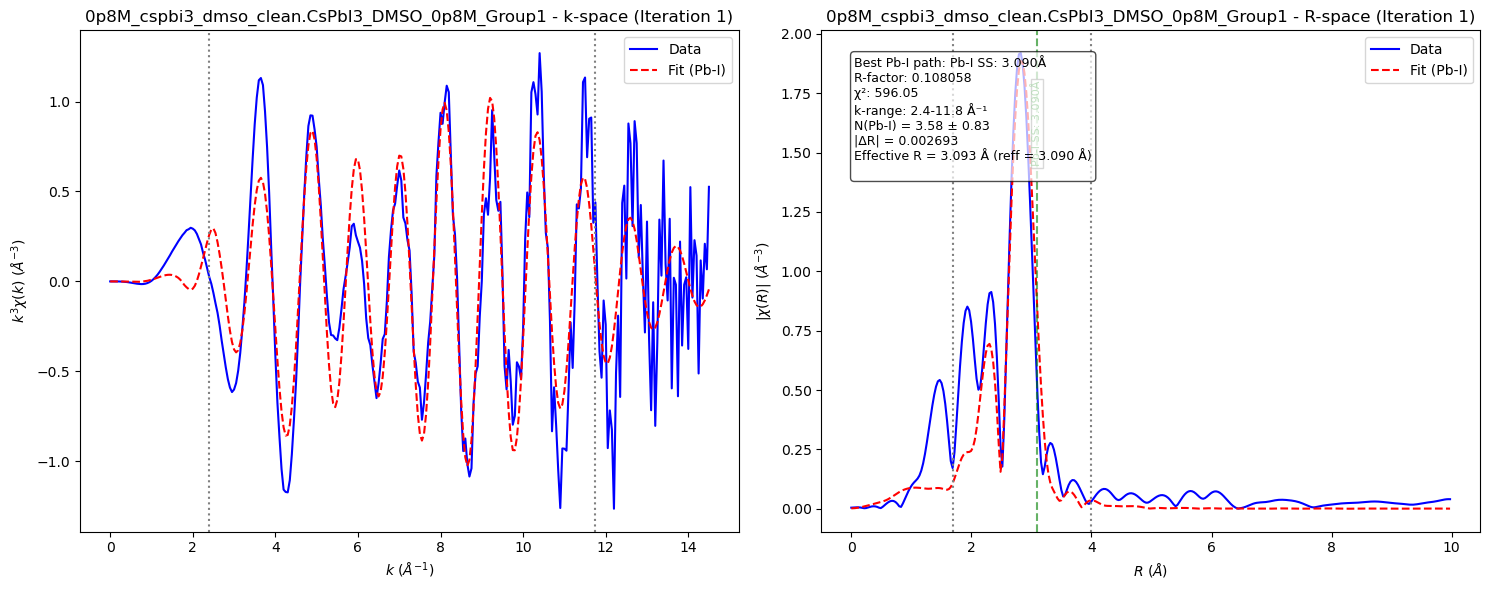


Processing Group: 0p8M_cspbi3_dmso_clean.CsPbI3_DMSO_0p8M_Group2

Processing group: 0p8M_cspbi3_dmso_clean.CsPbI3_DMSO_0p8M_Group2
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.40 (from ft_processing_batch)
  Found optimized kmax = 11.80 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.40 to 11.80 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p8M_cspbi3_dmso_clean.CsPbI3_DMSO_0p8M_Group2...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440df66150>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.050, R-factor: 1.071994
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440f1bfd40>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.090, R-factor: 1.073557
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440f160980>
  Path 3: Pb-I SS: 2.881Å - |ΔR|: 0.119, R-f

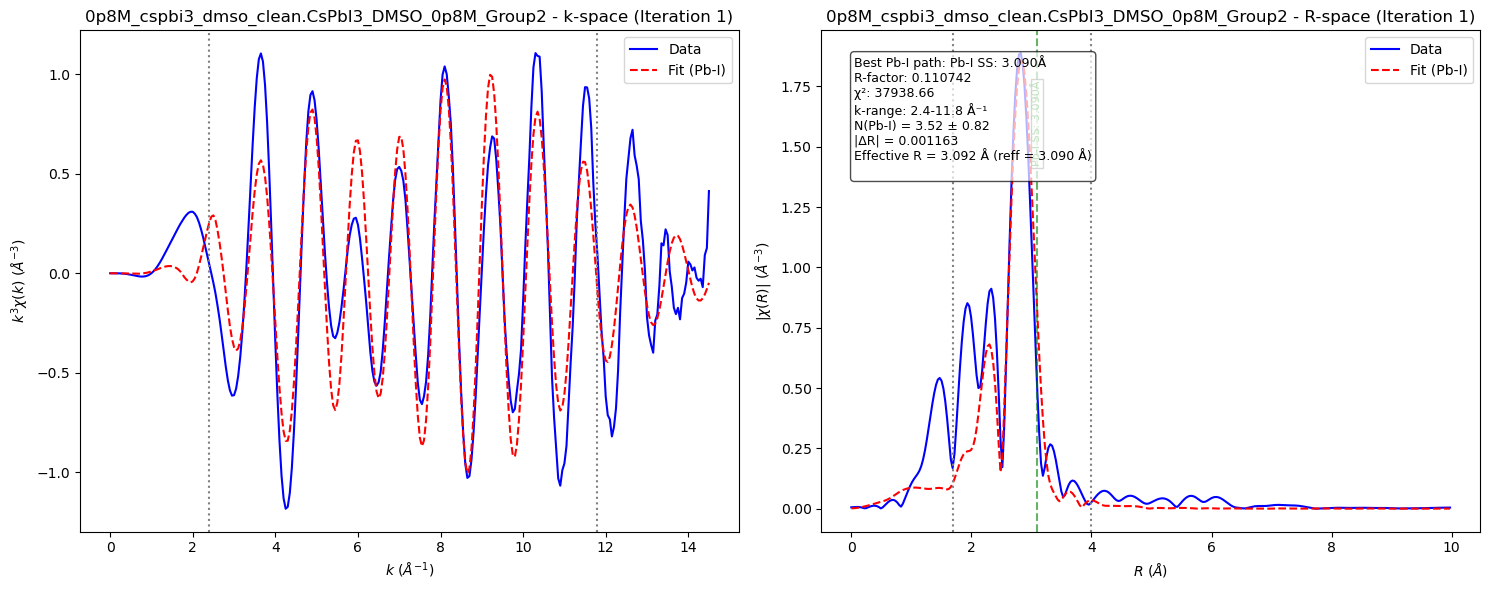


Processing Project: 0p9M_cspbi3_dmso_clean

Processing Group: 0p9M_cspbi3_dmso_clean.CsPbI3_DMSO_0p9M_Group1

Processing group: 0p9M_cspbi3_dmso_clean.CsPbI3_DMSO_0p9M_Group1
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.35 (from ft_processing_batch)
  Found optimized kmax = 11.80 (from ft_processing_batch)
  Using rbkg reference = 1.18 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.35 to 11.80 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p9M_cspbi3_dmso_clean.CsPbI3_DMSO_0p9M_Group1...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440f1be930>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.068, R-factor: 1.141790
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440f0344d0>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.100, R-factor: 1.141265
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440f442150>


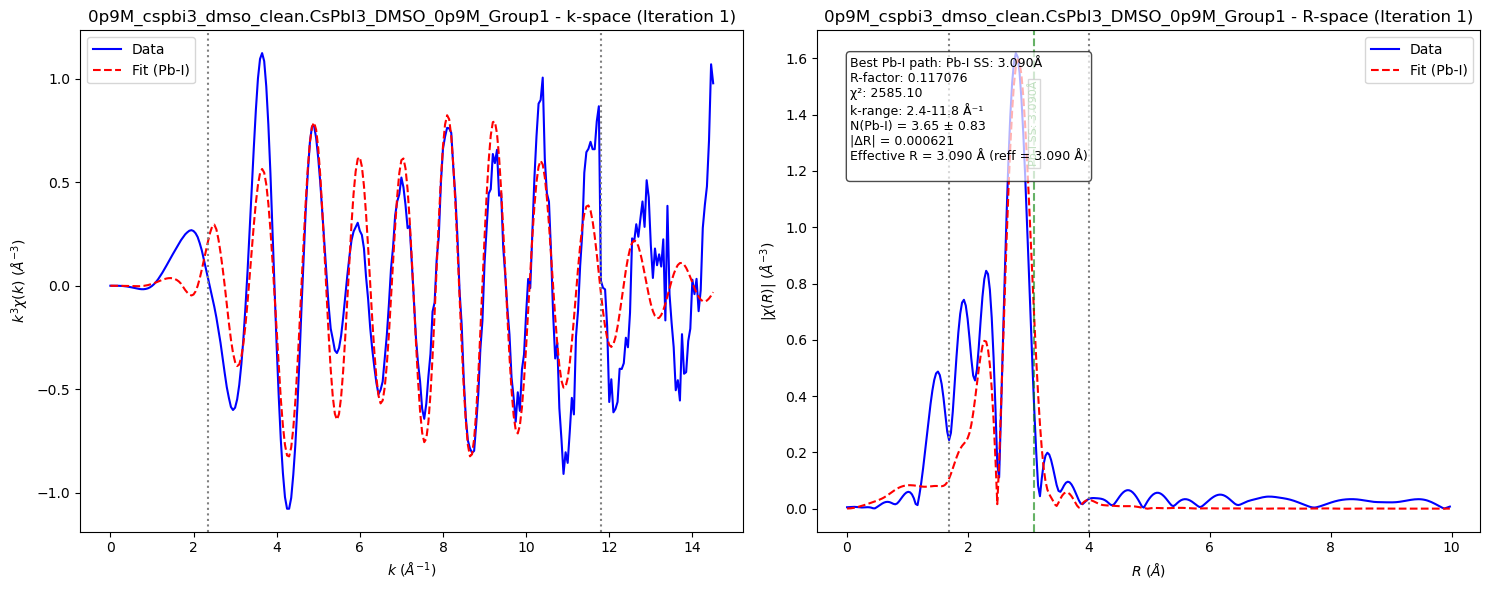


Processing Group: 0p9M_cspbi3_dmso_clean.CsPbI3_DMSO_0p9M_Group2

Processing group: 0p9M_cspbi3_dmso_clean.CsPbI3_DMSO_0p9M_Group2
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.35 (from ft_processing_batch)
  Found optimized kmax = 11.85 (from ft_processing_batch)
  Using rbkg reference = 1.18 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.35 to 11.85 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 0p9M_cspbi3_dmso_clean.CsPbI3_DMSO_0p9M_Group2...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440f091820>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.200, R-factor: 1.017442
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440df0de20>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.100, R-factor: 1.149427
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dd32150>
  Path 3: Pb-I SS: 2.881Å - |ΔR|: 0.200, R-f

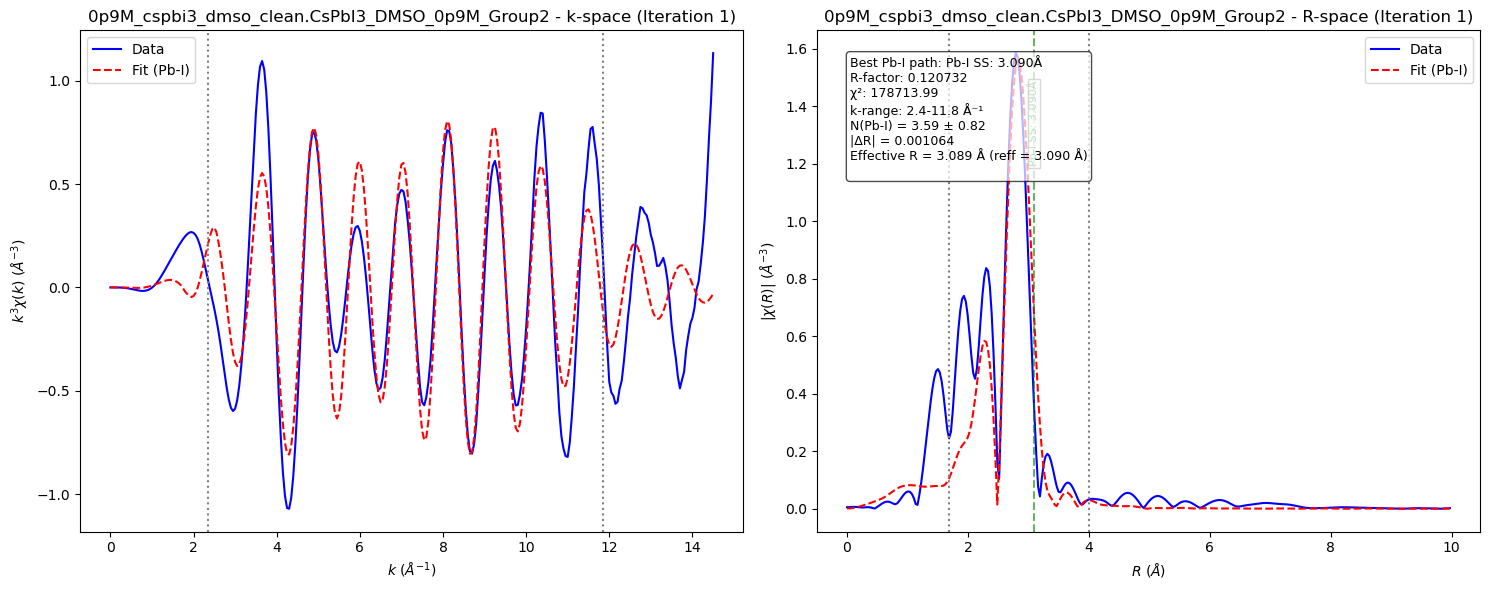


Processing Project: 1p0M_cspbi3_dmso_clean

Processing Group: 1p0M_cspbi3_dmso_clean.CsPbI3_DMSO_1p0M_Group1

Processing group: 1p0M_cspbi3_dmso_clean.CsPbI3_DMSO_1p0M_Group1
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.40 (from ft_processing_batch)
  Found optimized kmax = 11.85 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.40 to 11.85 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 1p0M_cspbi3_dmso_clean.CsPbI3_DMSO_1p0M_Group1...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b1908c0>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.200, R-factor: 1.016553
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b10d2e0>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.200, R-factor: 1.081800
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dee0e60>


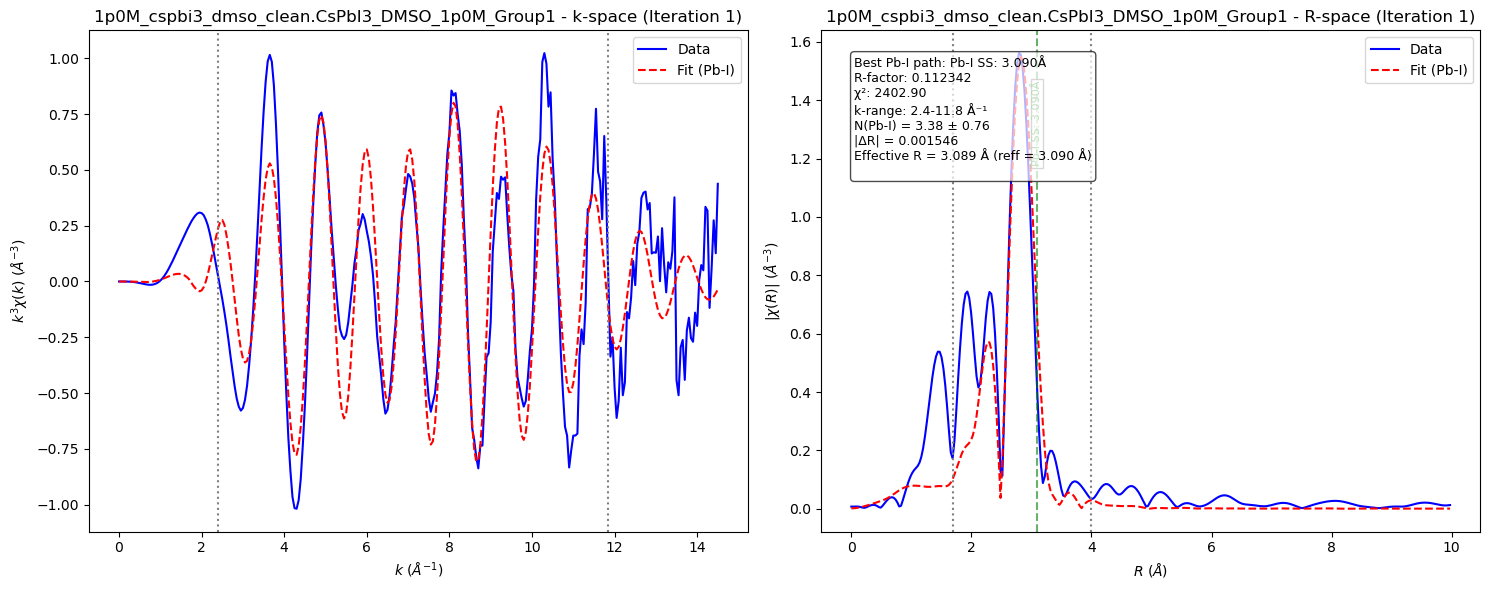


Processing Group: 1p0M_cspbi3_dmso_clean.CsPbI3_DMSO_1p0M_Group2

Processing group: 1p0M_cspbi3_dmso_clean.CsPbI3_DMSO_1p0M_Group2
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.40 (from ft_processing_batch)
  Found optimized kmax = 11.85 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.69 A (detected)
  Created transform with k-range: 2.40 to 11.85 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 1p0M_cspbi3_dmso_clean.CsPbI3_DMSO_1p0M_Group2...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440ca654c0>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.200, R-factor: 1.022908
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440dc31ac0>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.200, R-factor: 1.088634
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b0bb200>
  Path 3: Pb-I SS: 2.881Å - |ΔR|: 0.200, R-f

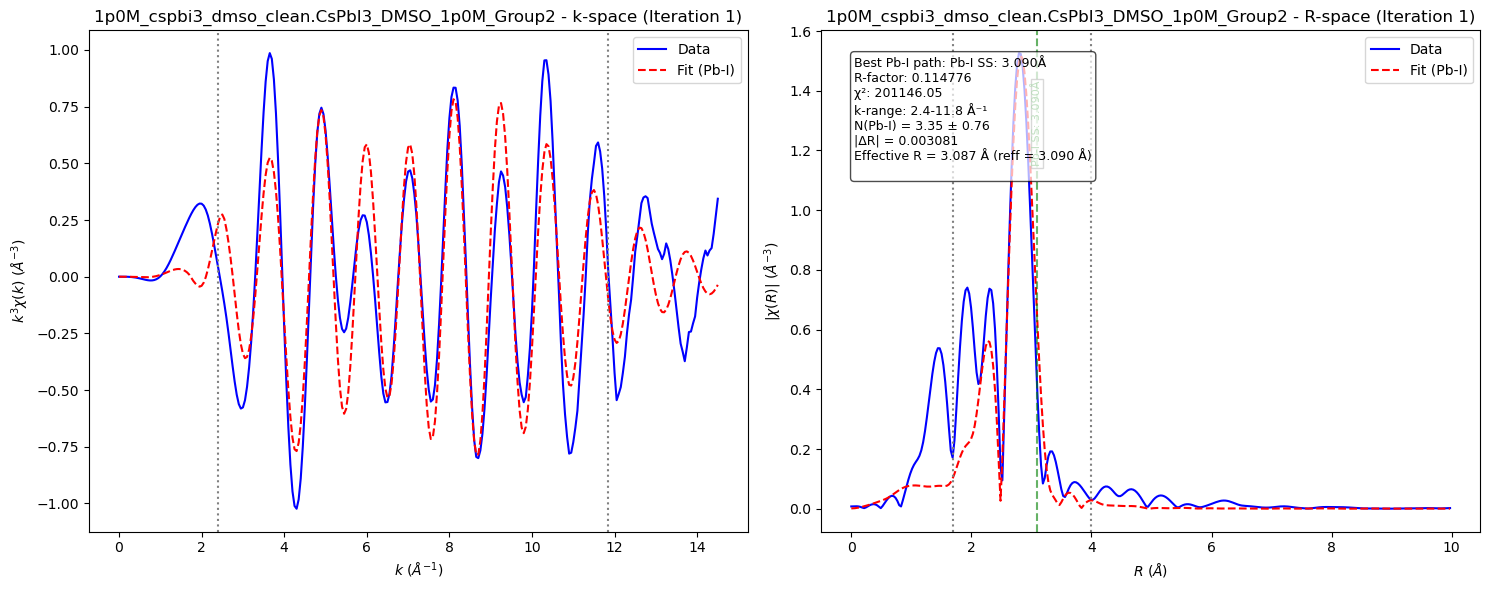


Processing Project: 1p2M_cspbi3_dmso_clean

Processing Group: 1p2M_cspbi3_dmso_clean.CsPbI3_DMSO_1p2M_Group1

Processing group: 1p2M_cspbi3_dmso_clean.CsPbI3_DMSO_1p2M_Group1
Creating Fourier Transform parameters for unknown...
  Found optimized kmin = 2.35 (from ft_processing_batch)
  Found optimized kmax = 11.95 (from ft_processing_batch)
  Using rbkg reference = 1.06 A
  Using fit rmin = 1.63 A (detected)
  Created transform with k-range: 2.35 to 11.95 Å⁻¹, kw=3
Evaluating 25 Pb-I paths for 1p2M_cspbi3_dmso_clean.CsPbI3_DMSO_1p2M_Group1...
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440c5991c0>
  Path 1: Pb-I SS: 2.812Å - |ΔR|: 0.200, R-factor: 1.029485
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440b0bb410>
  Path 2: Pb-I SS: 2.843Å - |ΔR|: 0.200, R-factor: 0.546782
Building parameter group for iteration 1...
  Created parameters for iteration 1: <Param Group 0x1440db099d0>


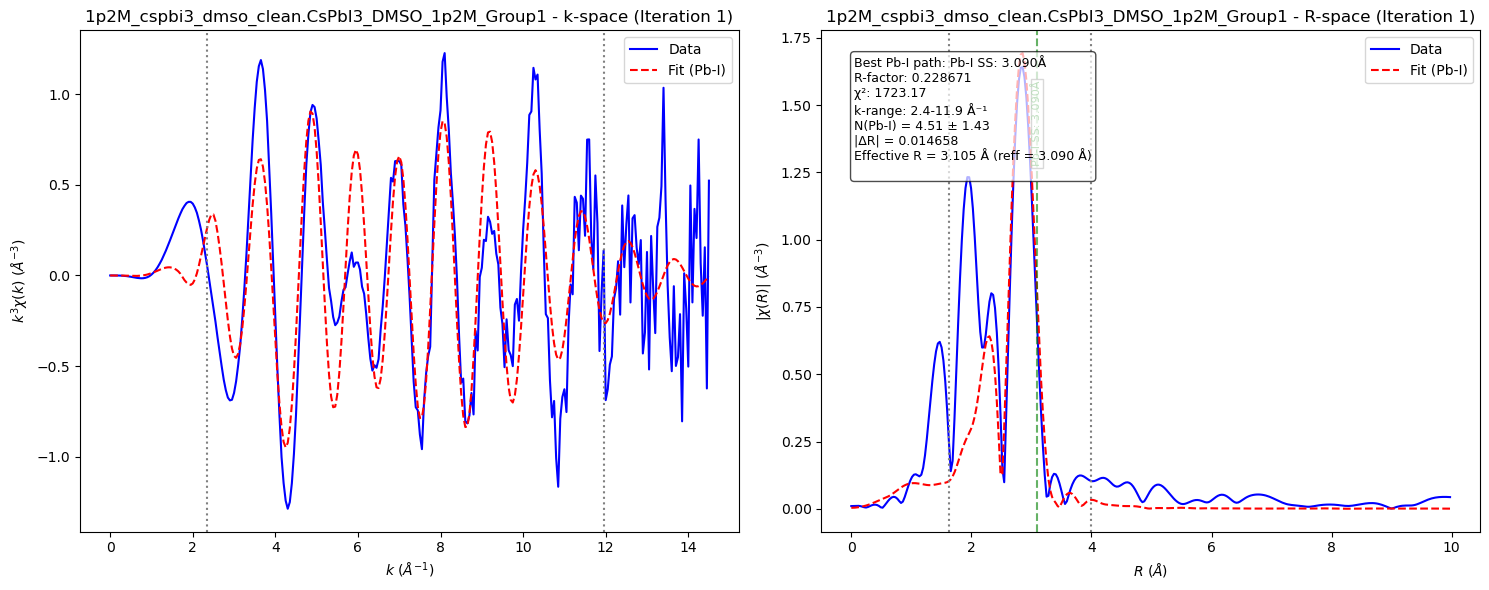


ITERATION 1 SUMMARY: BEST Pb-I PATHS FOR ALL GROUPS
Successfully processed 20 groups
----------------------------------------------------------------------------------------------------
Group                          Path                      Reff    |ΔR|    N(Pb-I) Eff. R  R-factor  
----------------------------------------------------------------------------------------------------
0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1M_Group1_clean_smooth Pb-I SS: 3.090Å           3.090 0.004 3.00 3.086 0.12814360
0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1M_Group2_clean_1 Pb-I SS: 3.000Å           3.000 0.075 3.17 3.075 0.08432483
0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1m_Group3_clean_deconv Pb-I SS: 3.090Å           3.090 0.002 3.49 3.089 0.11423967
0p2M_cspbi3_dmso_clean.CsPbI3_DMSO_0p2M_Group1_clean Pb-I SS: 3.090Å           3.090 0.004 3.43 3.094 0.11058457
0p2M_cspbi3_dmso_clean.CsPbI3_DMSO_0p2M_Group2 Pb-I SS: 3.090Å           3.090 0.001 3.38 3.092 0.11176468
0p3M_cspbi3_dmso_clean.CsPbI3_DMSO_0p

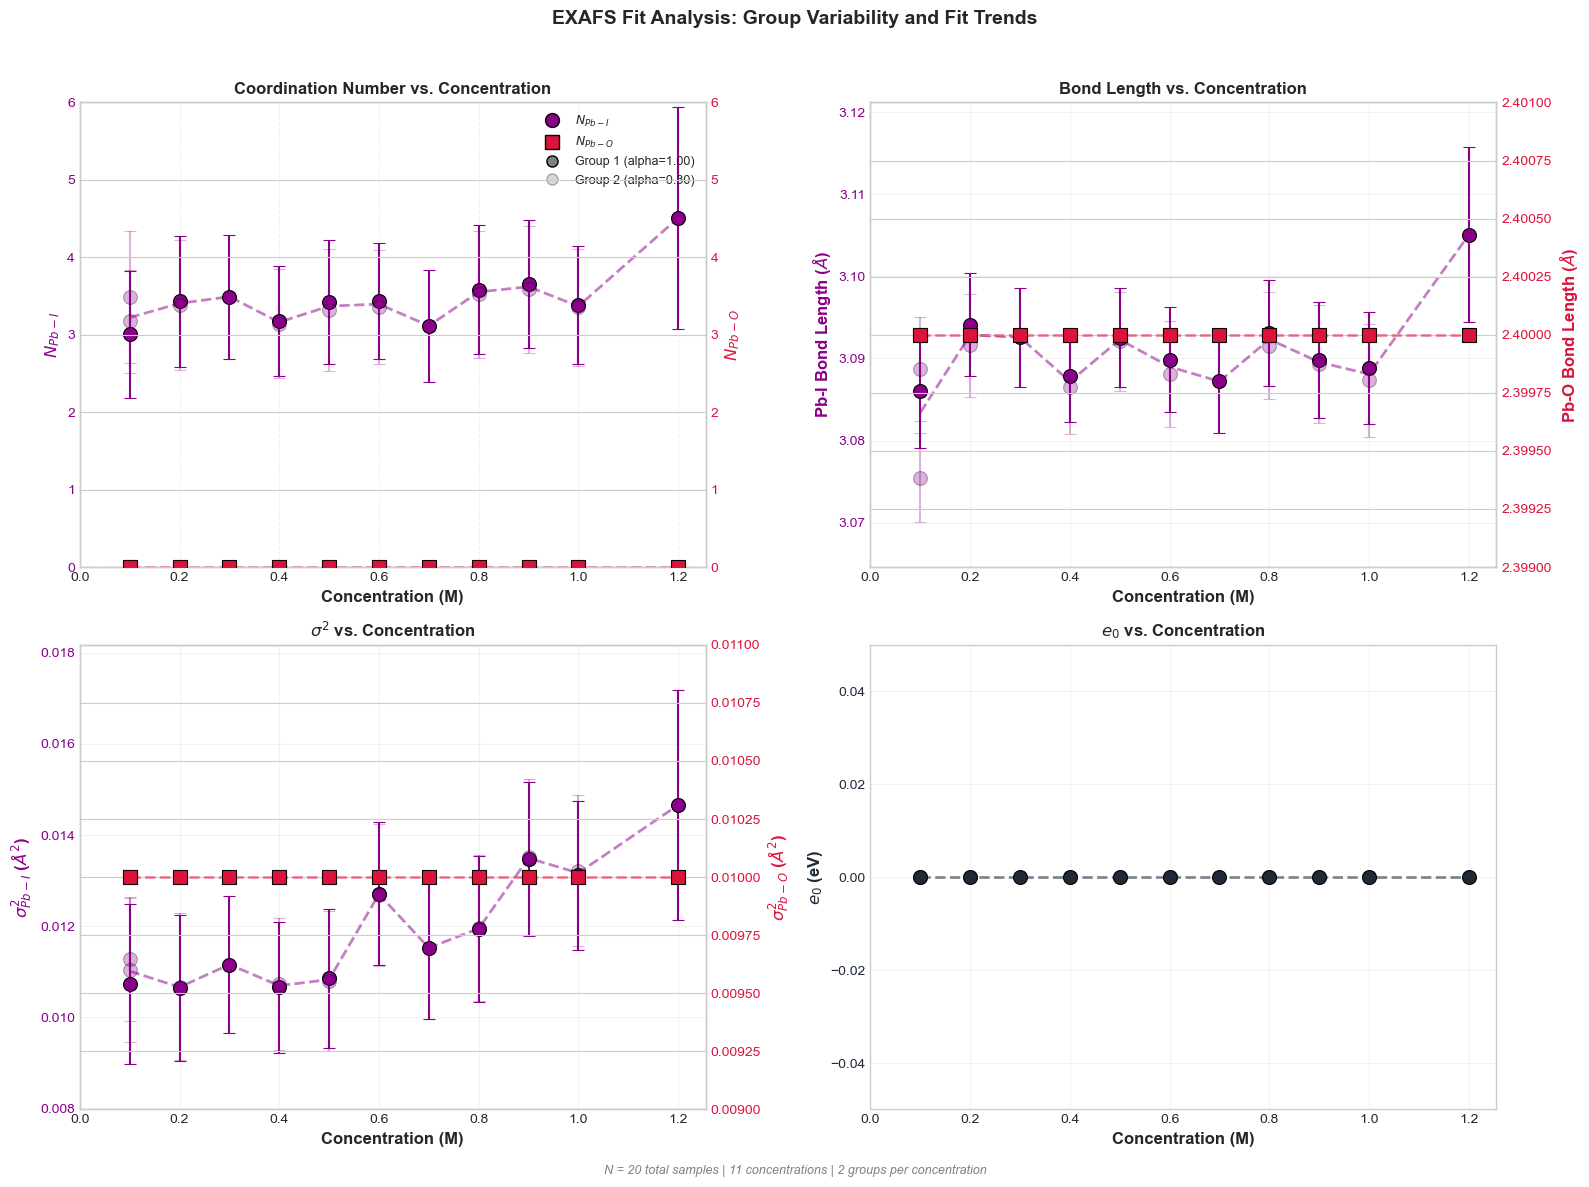


PLOT_FIT_2X2_SUMMARY
  Total groups:      20
  Concentrations:    11
  Figure saved:      Not saved
--------------------------------------------------------------------------------
  Per-concentration summary:
    Conc 0.100 M: 3 groups, avg N_I=3.22, avg N_O=0.00, avg sigma2_I=0.01102, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.200 M: 2 groups, avg N_I=3.41, avg N_O=0.00, avg sigma2_I=0.01066, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.300 M: 1 groups, avg N_I=3.49, avg N_O=0.00, avg sigma2_I=0.01116, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.400 M: 2 groups, avg N_I=3.16, avg N_O=0.00, avg sigma2_I=0.01070, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.500 M: 2 groups, avg N_I=3.37, avg N_O=0.00, avg sigma2_I=0.01083, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.600 M: 2 groups, avg N_I=3.40, avg N_O=0.00, avg sigma2_I=0.01270, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.700 M: 1 groups, avg N_I=3.12, avg N_O=0.00, avg sigma2_I=0.01153, avg sigma2_O=0.01000, avg e0=0.00

In [3]:
# 1. Add Pb-I
cspbi3_fit.enhanced_iteration1_fit(feff_dir, e0=0, vary_e0=False)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)



AICc improvement threshold for Pb-O: 0.000
Pb-O AIMD single-shell enabled: mode=restrain, sigma2 target=0.055225 A^2, restraint strength=0.1
Searching for candidate 'Pb-O' paths in C:\Users\kwill\.larch\feff...
Found 1959 candidate paths for category 'Pb-O'.
    1: Pb-O SS: 2.233Å, reff = 2.233 Å
    2: Pb-O SS: 2.237Å, reff = 2.237 Å
    3: Pb-O SS: 2.241Å, reff = 2.241 Å
    4: Pb-O SS: 2.248Å, reff = 2.248 Å
    5: Pb-O SS: 2.288Å, reff = 2.288 Å
      ... (1954 more paths)

Pb-O SPLIT TWO-SHELL MODEL
  sigma^2 fixed at 0.0250 A^2 (AIMD-informed)
  split_O constrained to [0.30, 0.38] A (target 0.34 A)
  N_O1, N_O2 in [0, 6]; N_total checked against 8
  AICc gate: ΔAICc <= 0.000
  No third cumulant.
  Path selection: Selected pair Reff_O1=2.434 A, Reff_O2=2.774 A, separation=0.340 A (target=0.34 A).

Processing project (split): 0p1M_cspbi3_dmso_clean

  Group: 0p1M_cspbi3_dmso_clean.CsPbI3_DMSO_0p1M_Group2_clean_1
Creating Fourier Transform parameters for unknown...
  Found optimized

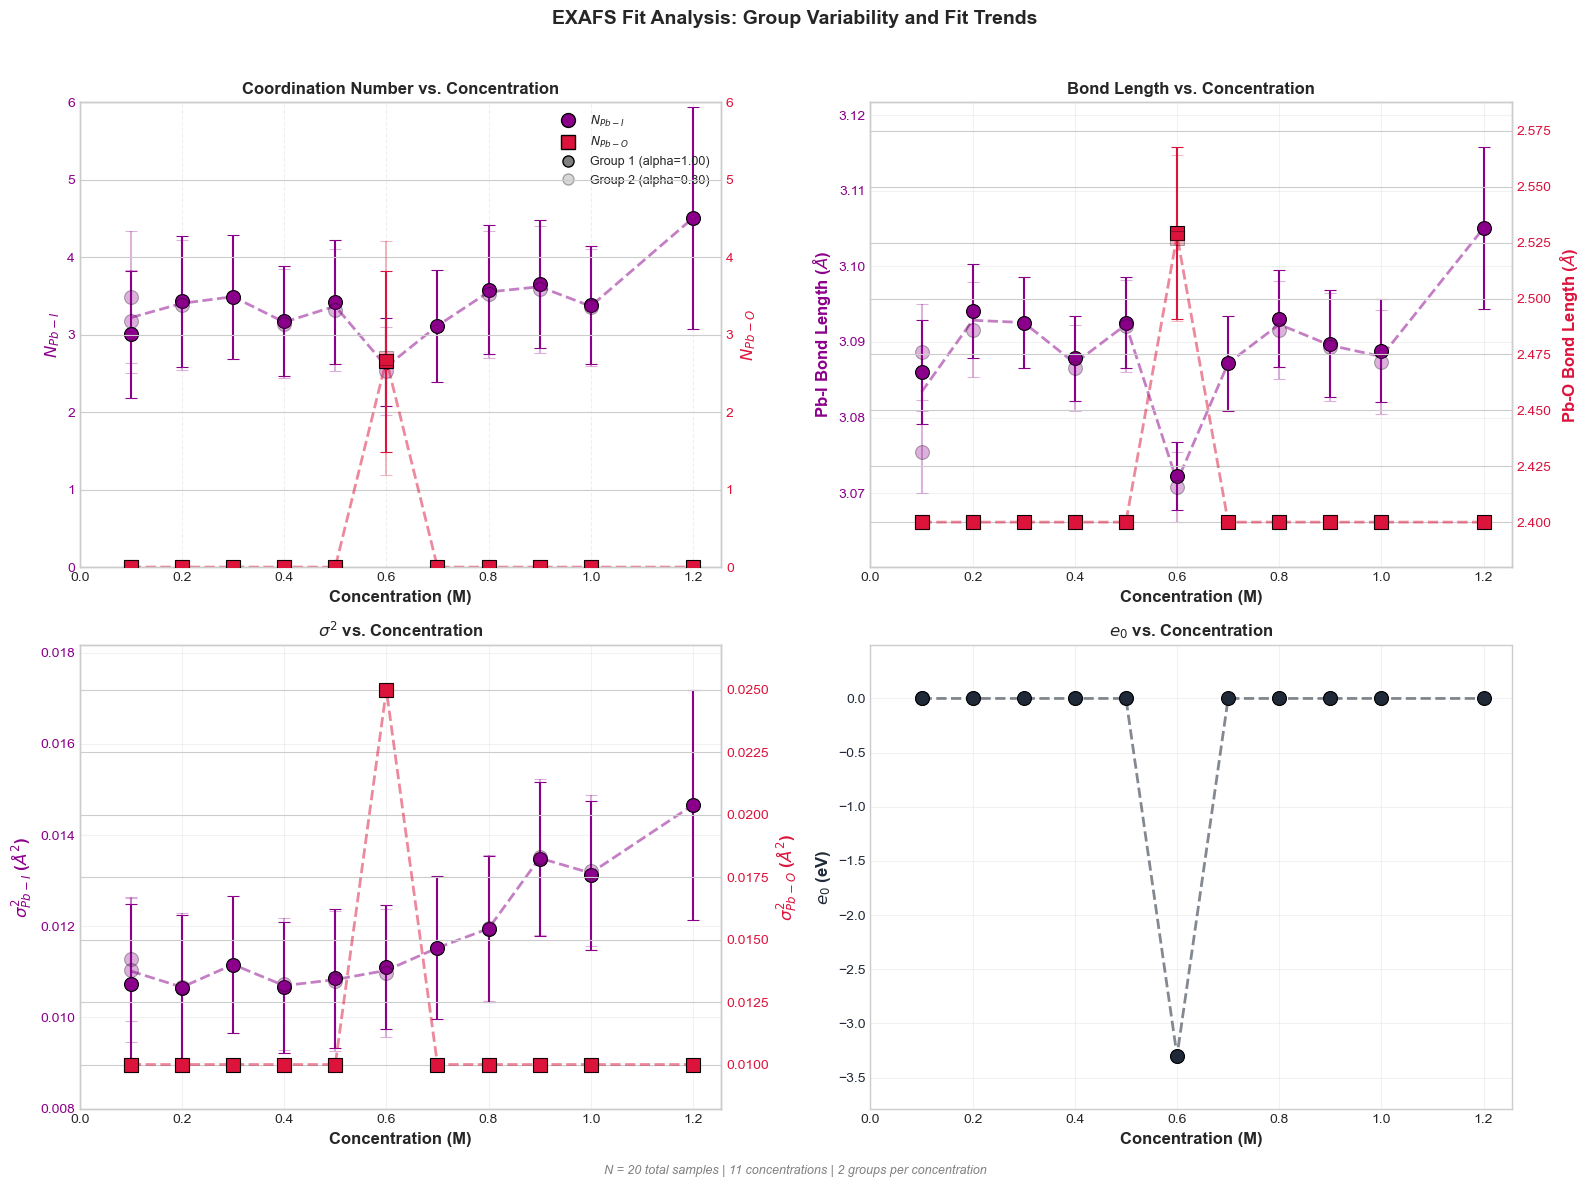


PLOT_FIT_2X2_SUMMARY
  Total groups:      20
  Concentrations:    11
  Figure saved:      Not saved
--------------------------------------------------------------------------------
  Per-concentration summary:
    Conc 0.100 M: 3 groups, avg N_I=3.22, avg N_O=0.00, avg sigma2_I=0.01102, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.200 M: 2 groups, avg N_I=3.41, avg N_O=0.00, avg sigma2_I=0.01066, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.300 M: 1 groups, avg N_I=3.49, avg N_O=0.00, avg sigma2_I=0.01116, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.400 M: 2 groups, avg N_I=3.16, avg N_O=0.00, avg sigma2_I=0.01070, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.500 M: 2 groups, avg N_I=3.37, avg N_O=0.00, avg sigma2_I=0.01083, avg sigma2_O=0.01000, avg e0=0.000
    Conc 0.600 M: 2 groups, avg N_I=2.59, avg N_O=2.68, avg sigma2_I=0.01103, avg sigma2_O=0.02500, avg e0=-3.300
    Conc 0.700 M: 1 groups, avg N_I=3.12, avg N_O=0.00, avg sigma2_I=0.01153, avg sigma2_O=0.01000, avg e0=0.0

In [5]:

# 2. Add Pb-O
cspbi3_fit.iterative_fit_all(
    'Pb-O',
    iteration=2,
    feff_base_dir=feff_dir,
    physical_sanity_mode='off',
    use_pb_o_aimd_single_shell=True,
    pb_o_sigma2_mode='restrain',
    pb_o_sigma2_restraint_strength=0.1,
    pb_o_aicc_improvement_threshold=0,
    pb_o_model='split_two_shell'
    
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)


In [ ]:

# 3. Replace Pb-I
cspbi3_fit.replace_large_delr_paths(
    iteration=2,
    feff_base_dir=feff_dir,
    delr_threshold=0.06,
    improvement_tolerance=0.0005,
    target_param_types=['SS_I'],
    strict_scatterers=False,
    max_candidates_per_path=20,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)


In [ ]:

cspbi3_fit.replace_large_delr_paths(
    iteration=2,
    feff_base_dir=feff_dir,
    delr_threshold=0.06,
    improvement_tolerance=0.0005,
    target_param_types=['SS_O'],
    strict_scatterers=False,
    max_candidates_per_path=20,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)

In [ ]:

# 4. Add Pb-S, forcing one path per model
results_pbs = cspbi3_fit.iterative_fit_linked_all(
    feff_category='Pb-S',
    iteration=3,
    feff_base_dir=feff_dir,
    include_ms=False,
    max_paths_to_add=1,
    verbose=True,
    force_add_path=False,
    force_add_min_paths=0,
    physical_sanity_mode='off',
    require_valid_aicc=True,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    vary_e0 = True,
    pb_o_model='split_two_shell'
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)


In [ ]:

# 5. Replace 
cspbi3_fit.replace_large_delr_paths(
    iteration=3,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_O'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)
cspbi3_fit.replace_large_delr_paths(
    iteration=3,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_I'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)


In [ ]:
#  Add Pb-C
results_pbs = cspbi3_fit.iterative_fit_linked_all(
    feff_category='Pb-Cs',
    iteration=4,
    feff_base_dir=feff_dir,
    include_ms=False,
    max_paths_to_add=1,
    verbose=True,
    force_add_path=False,
    force_add_min_paths=1,
    physical_sanity_mode='off',
    require_valid_aicc=True,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    vary_e0 = True,
    pb_o_model='split_two_shell',
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)

In [ ]:
# replace
cspbi3_fit.replace_large_delr_paths(
    iteration=4,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_O'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)
cspbi3_fit.replace_large_delr_paths(
    iteration=4,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_I'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)

cspbi3_fit.replace_large_delr_paths(
    iteration=4,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_S'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)
cspbi3_fit.replace_large_delr_paths(
    iteration=4,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_C'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)


In [ ]:


# 6. Add MS
cspbi3_fit.iterative_fit_linked_all(
    feff_category='MS',
    iteration=5,
    feff_base_dir=feff_dir,
    include_ms=True,
    max_paths_to_add=2,
    verbose=True,
    physical_sanity_mode='off',
    require_valid_aicc=True,
    allow_rfactor_fallback=True,
    vary_e0=True,
    pb_o_model='split_two_shell',
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)


In [ ]:
# replace

cspbi3_fit.replace_large_delr_paths(
    iteration=5,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_I'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)

cspbi3_fit.replace_large_delr_paths(
    iteration=5,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_S'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)
cspbi3_fit.replace_large_delr_paths(
    iteration=5,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_C'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)

cspbi3_fit.replace_large_delr_paths(
    iteration=5,
    feff_base_dir=feff_dir,
    delr_threshold=0.08,
    improvement_tolerance=0.0005,
    target_param_types=['SS_O'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=False,
    vary_e0 = True
)

fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)


In [ ]:
cspbi3_fit.show_integrated_fit_paths()
cspbi3_fit.show_integrated_fit_paths(latest_only=False)
summary = cspbi3_fit.show_integrated_fit_paths(verbose=False)


In [ ]:
cspbi3_fit.plot_group_transparency_figure(
    figsize=(12, 10),      # Figure size
    dpi=300,               # Resolution for saved figure
    save_path=None,        # Path to save (None = display only)
    n_groups=3,            # Expected groups per concentration
    alpha_range=(1.0, 0.3) # (group1 alpha, group3 alpha)
)

cspbi3_fit.plot_publication_figure(
    figsize=(16, 12),        # Figure dimensions
    dpi=300,                 # Resolution for saving
    save_path='figure.png',  # None to display only
    include_paths_panel=True # Show path contributions
)

In [ ]:
# Replace any remaining large delr paths
cspbi3_fit.replace_large_delr_paths(
    iteration=5,
    feff_base_dir=feff_dir,
    delr_threshold=0.06,
    improvement_tolerance=0.0005,
    target_param_types=['SS_O', 'SS_I', 'SS_S', 'SS_C'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=False,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=True,
    vary_e0=True
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)


In [ ]:

results_pbs = cspbi3_fit.iterative_fit_linked_all(
    feff_category='Pb-S',
    iteration=6,
    feff_base_dir=feff_dir,
    include_ms=False,
    max_paths_to_add=1,
    verbose=True,
    force_add_path=False,
    force_add_min_paths=1,
    physical_sanity_mode='off',
    require_valid_aicc=True,
    allow_rfactor_fallback=True,
    reject_on_bound_pinning=False,
    pb_o_model='split_two_shell',
    vary_e0=True,
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)

In [ ]:
cspbi3_fit.replace_large_delr_paths(
    iteration=5,
    feff_base_dir=feff_dir,
    delr_threshold=0.06,
    improvement_tolerance=0.0005,
    target_param_types=['Pb-S'],
    strict_scatterers=False,
    max_candidates_per_path=8,
    max_total_replacements_per_group=1,
    require_delr_improvement=True,
    sanity_scope='off',
    require_valid_aicc=False,
    allow_rfactor_fallback=False,
    reject_on_bound_pinning=False,
    verbose=True,
    plot_results=True,
    vary_e0=True,
)
fig, axes = cspbi3_fit.plot_fit_2x2_summary(
    figsize=(16, 12),
    dpi=300,
    save_path=None,
    n_groups=2,
)
